In [1]:
import pandas as pd

In [2]:
customers=pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")


In [3]:
customers.head(5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.shape

(99441, 5)

In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [6]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
orders.shape

(99441, 8)

In [8]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [9]:
orders.duplicated().sum()

np.int64(0)

In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])

In [13]:
orders['year']=orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['day']=orders['order_purchase_timestamp'].dt.day
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017,10,2
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018,7,24
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018,8,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017,11,18
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018,2,13


In [14]:
orders.dropna(inplace=True)

In [15]:
payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [16]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
year                             0
month                            0
day                              0
dtype: int64

In [17]:
orders.describe()

,order_purchase_timestamp,year,month,day
count,96461,96461.000000,96461.000000,96461.000000
mean,2018-01-01 23:53:26.642249216,2017.544324,6.031785,15.515524
min,2016-09-15 12:16:38,2016.000000,1.000000,1.000000
25%,2017-09-14 09:28:28,2017.000000,3.000000,8.000000
50%,2018-01-20 19:59:42,2018.000000,6.000000,15.000000
75%,2018-05-05 18:33:24,2018.000000,8.000000,23.000000
max,2018-08-29 15:00:37,2018.000000,12.000000,31.000000
std,NaN,0.503664,3.228374,8.665804


In [18]:
orders.drop_duplicates(inplace=True)

In [19]:

df = orders.merge(customers, on='customer_id') \
           .merge(order_items, on='order_id') \
           .merge(payments, on='order_id') \
           .merge(products, on='product_id')

In [20]:
df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,...,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017,10,...,1,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017,10,...,1,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017,10,...,1,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0


In [21]:
df.shape

(115018, 33)

In [22]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'year', 'month', 'day', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm'],
      dtype='object')

In [23]:
df['payment_value'].sum()

np.float64(19773394.7)

In [24]:
# Monthly Sales Trend
df['month']=df['order_purchase_timestamp'].dt.to_period('M')


<Axes: xlabel='month'>

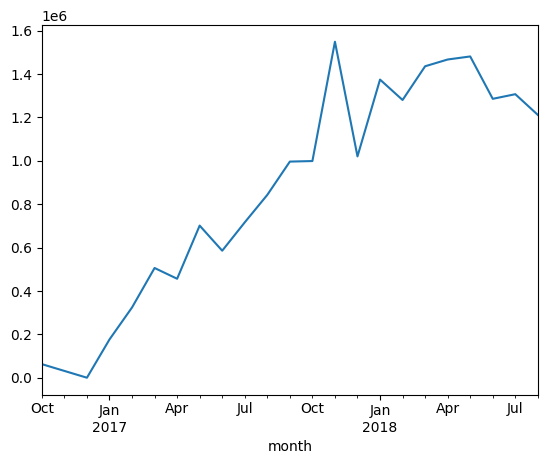

In [23]:
monthly_sales=df.groupby('month')['payment_value'].sum()
monthly_sales.plot()

In [25]:
# Calculating Top Products
top_products = df.groupby('product_id')['payment_value'].sum().sort_values(ascending=False).head(10)

In [26]:
# Calculating Top Customers
top_customers= df.groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending=False).head(10)

# RFM Analysis

In [27]:
# creating snapshot date
snapshot_date=df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [28]:
rfm=df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
    })
rfm.columns=['Recency','Frequency','Monetary']

In [29]:
rfm['R']=pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F']=pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M']=pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [30]:
# 444-best customers, 111-worst/risky customers
rfm['Segment']=rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

In [31]:
rfm['Segment'].value_counts()

Segment
444    2831
344    2788
244    2746
144    2564
232    1752
       ... 
342     946
141     879
341     860
241     846
441     825
Name: count, Length: 64, dtype: int64

In [34]:
rfm.rename(columns={'Segment':'RFM Score'}, inplace=True)

In [35]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,3,213


In [36]:
rfm.describe()

,Recency,Frequency,Monetary
count,93341.000000,93341.000000,93341.000000
mean,237.922531,1.232234,211.840399
std,152.577070,0.819824,642.219884
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.740000
50%,219.000000,1.000000,112.950000
75%,346.000000,1.000000,201.740000
max,695.000000,75.000000,109312.640000


In [41]:
rfm.drop(columns=['Segment'])

,Recency,Frequency,Monetary,R,F,M,RFM Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,3,213
...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,447,2,4134.84,1,4,4,144
fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58,2,4,2,242
ffff371b4d645b6ecea244b27531430a,568,1,112.46,1,4,2,142


In [42]:

# customer segmentation
def segment_customer(row):
    if row['R'] == 4 and row['F'] == 4 and row['M'] == 4:
        return 'Champions'
    elif row['F'] >= 3 and row['M'] >= 3:
        return 'Loyal Customers'
    elif row['R'] == 4:
        return 'New Customers'
    elif row['R'] <= 2 and row['F'] >= 3:
        return 'At Risk'
    elif row['R'] == 1:
        return 'Lost Customers'
    else:
        return 'Average Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [43]:
rfm.head(4)

,Recency,Frequency,Monetary,R,F,M,RFM Score,Segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413,New Customers
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311,Average Customers
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,Lost Customers
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Average Customers


In [ ]:
rfm['Segment'].value_counts() # customers per segment

Segment
Average Customers    28267
Loyal Customers      23321
New Customers        16707
Lost Customers       11735
At Risk              10480
Champions             2831
Name: count, dtype: int64

In [46]:
# Linking rfm segment to main orders data
df = df.merge(rfm[['Segment']], left_on='customer_unique_id', right_index=True)

In [48]:
df['total_price']=df['price']*df['freight_value']

<Axes: xlabel='Segment'>

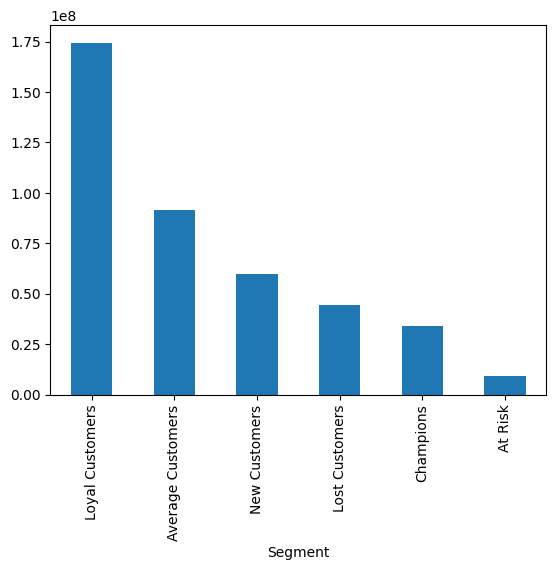

In [51]:
# Revenue by Segment
segment_revenue=df.groupby('Segment')['total_price'].sum().sort_values(ascending=False)
segment_revenue.plot(kind='bar')

In [52]:
print(segment_revenue)

Segment
Loyal Customers      1.745093e+08
Average Customers    9.174944e+07
New Customers        5.962326e+07
Lost Customers       4.453454e+07
Champions            3.399018e+07
At Risk              9.033064e+06
Name: total_price, dtype: float64


In [53]:
# Average order value by segment
df.groupby('Segment')['total_price'].mean()

Segment
At Risk               745.794570
Average Customers    3167.924741
Champions            4887.860377
Lost Customers       3795.018160
Loyal Customers      4598.278763
New Customers        3445.634695
Name: total_price, dtype: float64

In [54]:
df.to_csv('final_dataset.csv', index=False)